# ANÁLISIS DE VIAJES EN TAXI EN CHICAGO

## Objetivo del análisis

Este proyecto analiza datos de viajes en taxi en Chicago con el objetivo de identificar patrones en la demanda, conocer las empresas y zonas con mayor actividad y evaluar si las condiciones climáticas están asociadas con cambios en la duración de los viajes entre el Loop y el Aeropuerto Internacional O'Hare.

# 1. ANÁLISIS EXPLORATORIO DE DATOS

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [55]:
taxi_company_df = pd.read_csv('project_sql_result_01.csv')
location_name_df = pd.read_csv('project_sql_result_04.csv')
weather_con_df = pd.read_csv('project_sql_result_07.csv')

## EXPLORACIÓN INICIAL DE LOS DATOS

In [56]:
taxi_company_df.head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [57]:
location_name_df.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


In [ ]:
# Vista inicial de los datos de viajes y condiciones climáticas.
weather_con_df.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


## ESTRUCTURA Y CALIDAD DE LOS DATOS

In [ ]:
# Estructura y tipos de datos del dataset de compañías de taxi.
taxi_company_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [ ]:
# Estructura y tipos de datos del dataset de ubicaciones.
location_name_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


In [95]:
# Estructura y tipos de datos del dataset de viajes y condiciones climáticas.
weather_con_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB


In [90]:
# Convertir start_ts al tipo datetime.
weather_con_df['start_ts'] = pd.to_datetime(weather_con_df['start_ts'])

La columna start_ts fue identificada como tipo object. Debido a que representa información temporal, se convirtió al tipo datetime para facilitar el análisis temporal posterior.

In [91]:
# Verificar la conversión del tipo de dato.
weather_con_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB


## VALORES AUSENTES

In [ ]:
# Valores ausentes en taxi_company_df.
taxi_company_df.isna().sum()

company_name    0
trips_amount    0
dtype: int64

In [ ]:
# Valores ausentes en location_name_df.
location_name_df.isna().sum()

dropoff_location_name    0
average_trips            0
dtype: int64

In [ ]:
# Valores ausentes en weather_con_df.
weather_con_df.isna().sum()

start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64

## REGISTROS DUPLICADOS

In [ ]:
# Valores duplicados en taxi_company_df.
taxi_company_df.duplicated().sum()

np.int64(0)

In [ ]:
# Valores duplicados en location_name_df.
location_name_df.duplicated().sum()

np.int64(0)

In [ ]:
# Valores duplicados en weather_con_df.
weather_con_df.duplicated().sum()

np.int64(197)

In [70]:
# Inspeccionar los registros duplicados antes de decidir su tratamiento.
weather_con_df[weather_con_df.duplicated()].head(20)

,start_ts,weather_conditions,duration_seconds
62,2017-11-11 06:00:00,Good,1260.0
74,2017-11-11 08:00:00,Good,1380.0
76,2017-11-04 09:00:00,Good,1380.0
117,2017-11-11 07:00:00,Good,1380.0
119,2017-11-04 14:00:00,Good,3300.0
125,2017-11-11 08:00:00,Good,1380.0
126,2017-11-11 09:00:00,Good,1380.0
130,2017-11-11 10:00:00,Good,1260.0
179,2017-11-11 06:00:00,Good,1260.0
190,2017-11-04 08:00:00,Good,1323.0


Se identificaron 197 registros aparentemente duplicados en weather_con_df. Sin embargo, el dataset no contiene un identificador único de viaje que permita determinar si corresponden al mismo trayecto o a viajes distintos con características idénticas. Por este motivo, se conservaron los registros para evitar eliminar observaciones potencialmente válidas.

# 2. PRINCIPALES DESTINOS

In [92]:
# Columnas disponibles en location_name_df.
location_name_df.head(3)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667


In [72]:
# Ordenar los destinos de mayor a menor según el promedio de viajes.
location_name_df.sort_values(by='average_trips', ascending=False).head(10)

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


Se identificaron los 10 barrios con mayor promedio de viajes finalizados.

In [73]:
# Seleccionar los 10 destinos con mayor promedio de viajes.
top_10_neighborhoods = location_name_df.sort_values(
    by='average_trips',
    ascending=False
).head(10)

In [ ]:
# Mostrar los 10 destinos con mayor promedio de viajes.
top_10_neighborhoods

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


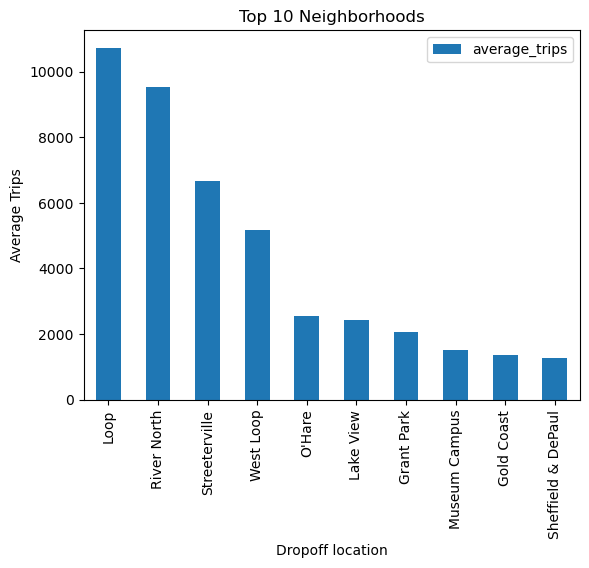

In [ ]:
# Visualizar los principales destinos.
top_10_neighborhoods.plot(title='Top 10 Neighborhoods', 
                          x='dropoff_location_name',
                          y='average_trips',
                          kind='bar',
                          xlabel='Dropoff location',
                          ylabel='Average Trips'
                         )
plt.show()

### Conclusiones
Loop presenta el mayor promedio de viajes finalizados y es el único barrio que supera los 10,000 viajes promedio. River North, Streeterville y West Loop también destacan, con más de 5,000 viajes promedio cada uno. Estos resultados muestran que los viajes finalizados se concentran principalmente en un grupo reducido de barrios, mientras que el resto de los destinos del top 10 registra promedios inferiores a 3,000 viajes.

# 3. EMPRESAS DE TAXIS

In [ ]:
# Número de compañías de taxi.
taxi_company_df.shape

(64, 2)

In [ ]:
# Columnas disponibles en taxi_company_df.
taxi_company_df.head(3)

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367


### Observaciones iniciales

El dataset taxi_company_df contiene información de 64 compañías de taxi y el número de viajes realizados por cada una durante el período analizado.

- El dataset contiene 64 registros, correspondientes a distintas compañías de taxi.
- La segunda columna (trips_amount) nos muestra el número de viajes realizados por cada compañía durante el período analizado.

In [ ]:
# Ordenar las compañías de mayor a menor según el número de viajes.
top_taxi_companies = taxi_company_df.sort_values(
    by='trips_amount',
    ascending=False
).head(10)

In [93]:
# Mostrar las principales compañías por número de viajes.
top_taxi_companies

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299
5,Chicago Carriage Cab Corp,9181
6,City Service,8448
7,Sun Taxi,7701
8,Star North Management LLC,7455
9,Blue Ribbon Taxi Association Inc.,5953


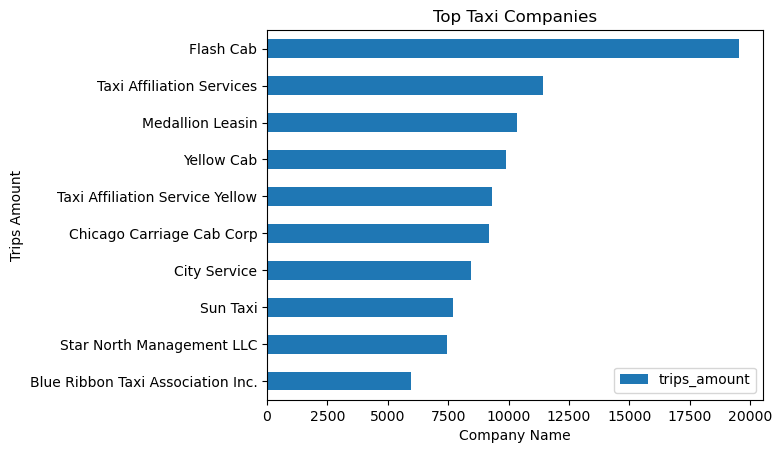

In [ ]:
# Visualizar las principales compañías de taxi.
top_taxi_companies.iloc[::-1].plot(title='Top Taxi Companies',
                       x='company_name',
                       y='trips_amount',
                       kind='barh',
                       xlabel='Company Name',
                       ylabel='Trips Amount'
                       )
plt.show()

### Conclusiones
Flash Cab es la compañía con el mayor número de viajes, con cerca de 20,000 durante el período analizado. Le siguen Taxi Affiliation Services y Medallion Leasing, siendo las únicas tres compañías que superan los 10,000 viajes. Los resultados muestran una concentración importante de viajes en las compañías líderes, con Flash Cab destacando claramente sobre el resto.

# 4. ANÁLISIS DEL IMPACTO DE LAS CONDICIONES CLIMÁTICAS

In [81]:
# Revisar las columnas disponibles del dataset
weather_con_df.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [82]:
# Revisar la estructura y los tipos de datos.
weather_con_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB


In [83]:
# Contar registros por condición climática.
weather_con_df['weather_conditions'].value_counts()

weather_conditions
Good    888
Bad     180
Name: count, dtype: int64

In [84]:
# Separar los datos por condición climática.
good_weather = weather_con_df[
    weather_con_df['weather_conditions'] == 'Good'
]

bad_weather = weather_con_df[
    weather_con_df['weather_conditions'] == 'Bad'
]

In [85]:
# Calcular la duración promedio de los viajes con condiciones climáticas favorables.

good_weather['duration_seconds'].mean()

np.float64(1999.6756756756756)

In [86]:
# Calcular la duración promedio de los viajes con condiciones climáticas desfavorables.
bad_weather['duration_seconds'].mean()

np.float64(2427.2055555555557)

In [87]:
# Calcular la diferencia en la duración promedio entre ambas condiciones climáticas.
print(bad_weather['duration_seconds'].mean() - good_weather['duration_seconds'].mean())

427.5298798798801


In [94]:
# Convertir la diferencia de duración de segundos a minutos.
print((bad_weather['duration_seconds'].mean() - good_weather['duration_seconds'].mean())/60)

7.125497997998002


De manera preliminar, se observa que los viajes presentan una menor duración promedio bajo condiciones climáticas favorables. La diferencia entre ambos grupos es de aproximadamente 7 minutos (428 segundos). Sin embargo, es necesario realizar una prueba estadística para determinar si esta diferencia es estadísticamente significativa.

# 5. PRUEBA DE HIPÓTESIS

### HIPÓTESIS NULA

La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es la misma en sábados con condiciones climáticas favorables y desfavorables.

### HIPÓTESIS ALTERNATIVA

La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es diferente en sábados con condiciones climáticas favorables y desfavorables.

Se estableció un nivel de significancia de α = 0.05, un umbral comúnmente utilizado en análisis estadísticos. Esto implica aceptar un riesgo del 5% de rechazar la hipótesis nula cuando en realidad es verdadera.

In [89]:
# Definimos el nivel de significancia
alpha = 0.05

# Separamos la duración de los viajes por condición climática
good_duration = good_weather['duration_seconds']
bad_duration = bad_weather['duration_seconds']

# Comprobamos la igualdad de varianzas con la prueba de Levene
levene_result = stats.levene(good_duration, bad_duration)

print('Levene p-value:', levene_result.pvalue)

# Determinamos si podemos asumir varianzas iguales
equal_variances = levene_result.pvalue > alpha

# Aplicamos la prueba t para dos muestras independientes
results = stats.ttest_ind(
    good_duration,
    bad_duration,
    equal_var=equal_variances
)

print('T-test p-value:', results.pvalue)

# Tomamos una decisión
if results.pvalue < alpha:
    print('Se rechaza la hipótesis nula.')
else:
    print('No se rechaza la hipótesis nula.')


Levene p-value: 0.5332038671974493
T-test p-value: 6.517970327099473e-12
Se rechaza la hipótesis nula.


### RESULTADOS DE LA PRUEBA DE HIPÓTESIS

Hipótesis Nula:

La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es la misma en sábados con condiciones climáticas favorables y desfavorables.

Hipótesis alternativa:

La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare es diferente en sábados con condiciones climáticas favorables y desfavorables.

Se utilizó una prueba t para dos muestras independientes con un nivel de significancia de α = 0.05 (5%).

El p-value obtenido fue aproximadamente 6.52 × 10⁻¹², considerablemente menor que α = 0.05. Por lo tanto, se rechaza la hipótesis nula. Los resultados proporcionan evidencia estadísticamente significativa de que la duración promedio de los viajes entre el Loop y el Aeropuerto Internacional O'Hare difiere entre los sábados con condiciones climáticas favorables y desfavorables.

## CONCLUSIONES GENERALES

El análisis permitió identificar patrones relevantes en la actividad de taxis de Chicago. Loop destaca como el principal destino por promedio de viajes finalizados, seguido por zonas como River North, Streeterville y West Loop.

Entre las compañías de taxi, Flash Cab registró el mayor número de viajes durante el período analizado, seguida por Taxi Affiliation Services y Medallion Leasing, lo que evidencia una concentración importante de viajes entre las compañías líderes.

En los viajes realizados los sábados entre el Loop y el Aeropuerto Internacional O'Hare, la duración promedio fue aproximadamente 7 minutos mayor bajo condiciones climáticas desfavorables que bajo condiciones favorables.

Finalmente, la prueba de hipótesis mostró que esta diferencia es estadísticamente significativa (p-value ≈ 6.52 × 10⁻¹²). Los resultados proporcionan evidencia de una asociación entre las condiciones climáticas y la duración de los viajes analizados, sin implicar necesariamente una relación causal.